In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Dataset publico de Kaggle - Superstore Sales
url = "https://raw.githubusercontent.com/jorisvandenbossche/pandas-tutorial/master/data/titanic.csv"
df =  pd.read_csv(url)

print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print(df.isnull().sum())
print(f"\nPorcentaje de nulos por columna:")
print((df.isnull().sum() / len(df) * 100).round(2))

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Porcentaje de nulos por columna:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [7]:
# Eliminar las 2 filas de Embarked
df = df.dropna(subset=['Embarked'])

# Rellenar Age con la mediana por clase
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# Cabin - crear variable binaria y liminar la original
df['Tiene_Cabina'] = df['Cabin'].notna().astype(int)
df = df.drop('Cabin', axis=1)

print(df.isnull().sum())

PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age             0
SibSp           0
Parch           0
Ticket          0
Fare            0
Embarked        0
Tiene_Cabina    0
dtype: int64


Survived
0    549
1    340
Name: count, dtype: int64
Survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


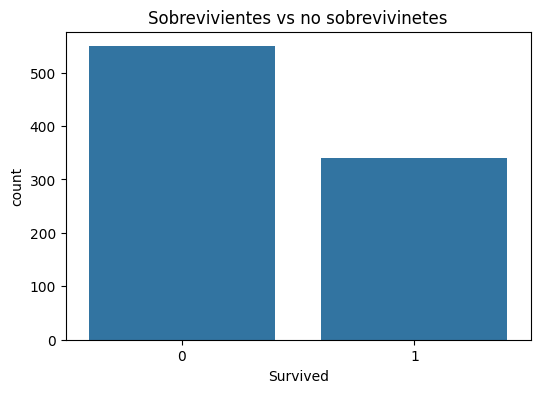

In [8]:
print(df['Survived'].value_counts())
print(df['Survived'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survived')
plt.title("Sobrevivientes vs no sobrevivinetes")
plt.show()

Sex
female    74.038462
male      18.890815
Name: Survived, dtype: float64


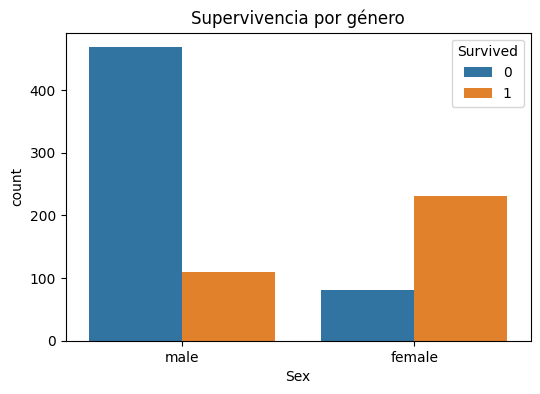

In [12]:
print(df.groupby('Sex')['Survived'].mean() * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Supervivencia por género")
plt.show()

Pclass
1    62.616822
2    47.282609
3    24.236253
Name: Survived, dtype: float64


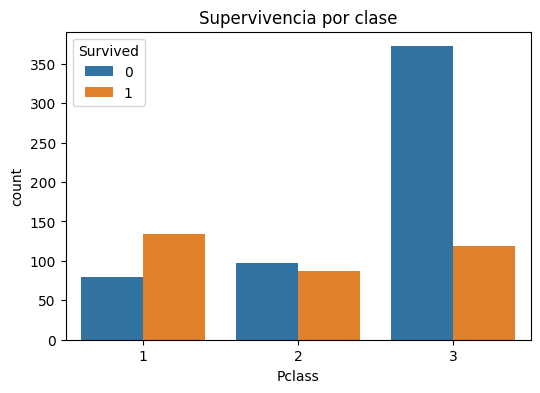

In [13]:
print(df.groupby('Pclass')['Survived'].mean() * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title("Supervivencia por clase")
plt.show()

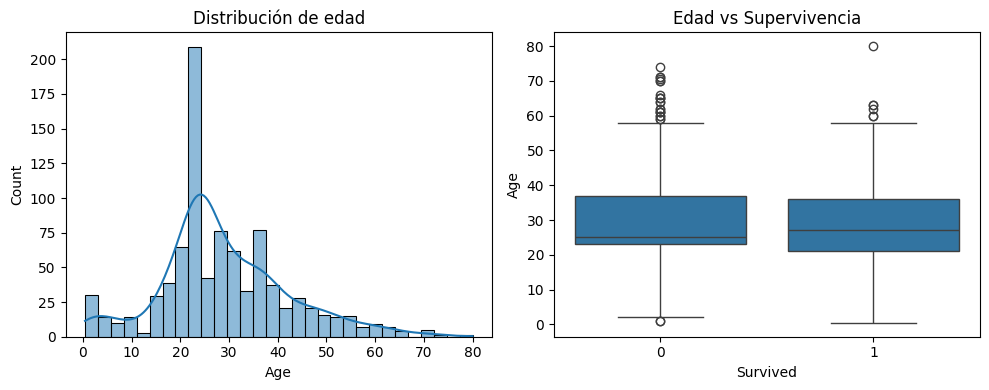

In [18]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.title("Distribución de edad")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Survived', y='Age')
plt.title("Edad vs Supervivencia")

plt.tight_layout()
plt.show()

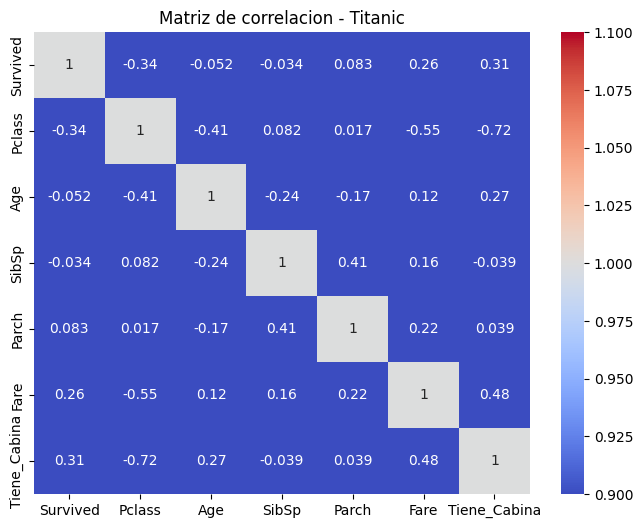

In [19]:
df_numerico = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Tiene_Cabina']]

plt.figure(figsize=(8, 6))
sns.heatmap(df_numerico.corr(), annot=True, cmap='coolwarm', vmin=1, vmax=1)
plt.title("Matriz de correlacion - Titanic")
plt.show()

## Hipotesis
**Tasa de supervivencia:** sobrevivio el 38.245% de la tripulacion, mientras que el 61.754% fallecio
**El principal factor en la supervivencia fue la clase social
**Del total de mujeres sobrevivio un 74.038%, mientras que de hombres unicamente un 18.890%
**La mayoria del total de pasajeros estaban en sus 20s
**Recomendaria tener mas salidas de emergencia, mas botes salvavidas, etc, ya que un 61% de fallecimiento es bastante alto, se tienen que cambiar varias cosas

## Hallazgos del EDA — Titanic

**Tasa de supervivencia general:** 38.2% sobrevivió, 61.8% falleció.

**Factor más influyente:** el género — 74% de las mujeres sobrevivieron 
vs solo 18.9% de los hombres, reflejando el protocolo "mujeres y niños primero".

**Segundo factor relevante:** la clase social — los pasajeros de primera 
clase tuvieron 62.6% de supervivencia, comparado con 24.2% en tercera clase.

**Demografía:** la mayoría de los pasajeros estaban en sus 20s.

**Recomendación:** la alta tasa de mortalidad (61.8%) sugiere protocolos 
de evacuación insuficientes — más botes salvavidas y salidas de emergencia 
habrían reducido significativamente las pérdidas, especialmente para los 
pasajeros de clases bajas que tuvieron menor acceso a la evacuación.